# Customer Segmentation — Clustering Notebook

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Clustering with Standard Scaler](#2-clustering-with-standard-scaler)
   - 2.1 K-Means
   - 2.2 Mean Shift
   - 2.3 Hierarchical Clustering
   - 2.4 DBSCAN
   - 2.5 SOM (Self-Organizing Map)
3. [Clustering with Robust Scaler](#3-clustering-with-robust-scaler)
   - 3.1 K-Means
   - 3.2 Mean Shift
   - 3.3 Hierarchical Clustering
   - 3.4 DBSCAN
   - 3.5 SOM (Self-Organizing Map)
4. [Clustering with MinMax Scaler](#4-clustering-with-minmax-scaler)
   - 4.1 K-Means
   - 4.2 Mean Shift
   - 4.3 Hierarchical Clustering
   - 4.4 DBSCAN
   - 4.5 SOM (Self-Organizing Map)
5. [Model Comparison](#5-model-comparison)

# 1. Setup & Data Loading

In [19]:
# Import necessary libraries for data processing and visualization
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Import all clustering algorithms and helper functions from Clustering.py
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, 
    fit_dbscan, compare_models, _initialize_som_weights, _find_bmu, 
    _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, 
    get_som_cluster_labels, assign_som_clusters, fit_meanshift, plot_umap
)

# Import preprocessing functions from Preprocessing.py
from Preprocessing import (
    preprocess_data_standardscaler, preprocess_data_robustscaler, 
    preprocess_data_minmaxscaler, cluster_analysis
)

In [20]:
# Load the engineered customer dataset
df = pd.read_csv('customer_info_engineered.csv')

# Preprocess and scale the dataset using Standard, Robust, and MinMax scalers
df_processed_st = preprocess_data_standardscaler(df)
df_processed_rb = preprocess_data_robustscaler(df)
df_processed_mm = preprocess_data_minmaxscaler(df)

KeyboardInterrupt: 

In [ ]:
# Define the selected subset of features for clustering (lifestyle & spend metrics)
healthy_options = [
    'lifetime_spend_vegetables', 
    'lifetime_spend_meat', 
    'lifetime_spend_fish',
    'lifetime_spend_alcohol_drinks', 
    'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_videogames', 
    'typical_hour', 
    'age'
]


In [ ]:
# Filter the scaled datasets to keep only the selected lifestyle features
df_saude_st = df_processed_st[healthy_options]
df_saude_rb = df_processed_rb[healthy_options]
df_saude_mm = df_processed_mm[healthy_options]

In [ ]:
# Run baseline profile analysis on the unscaled customer dataset
df_cluster_anaylsis = cluster_analysis(df)

# 2. Clustering with Standard Scaler

## 2.1 K-Means

k=2 | Inertia: 196156.50 | Silhouette: 0.3089
k=3 | Inertia: 155459.26 | Silhouette: 0.2547
k=4 | Inertia: 140629.44 | Silhouette: 0.2207
k=5 | Inertia: 129297.77 | Silhouette: 0.2174
k=6 | Inertia: 122004.73 | Silhouette: 0.2161
k=7 | Inertia: 114999.57 | Silhouette: 0.1983
k=8 | Inertia: 109222.34 | Silhouette: 0.1805
k=9 | Inertia: 104916.76 | Silhouette: 0.1792
k=10 | Inertia: 100776.97 | Silhouette: 0.1810


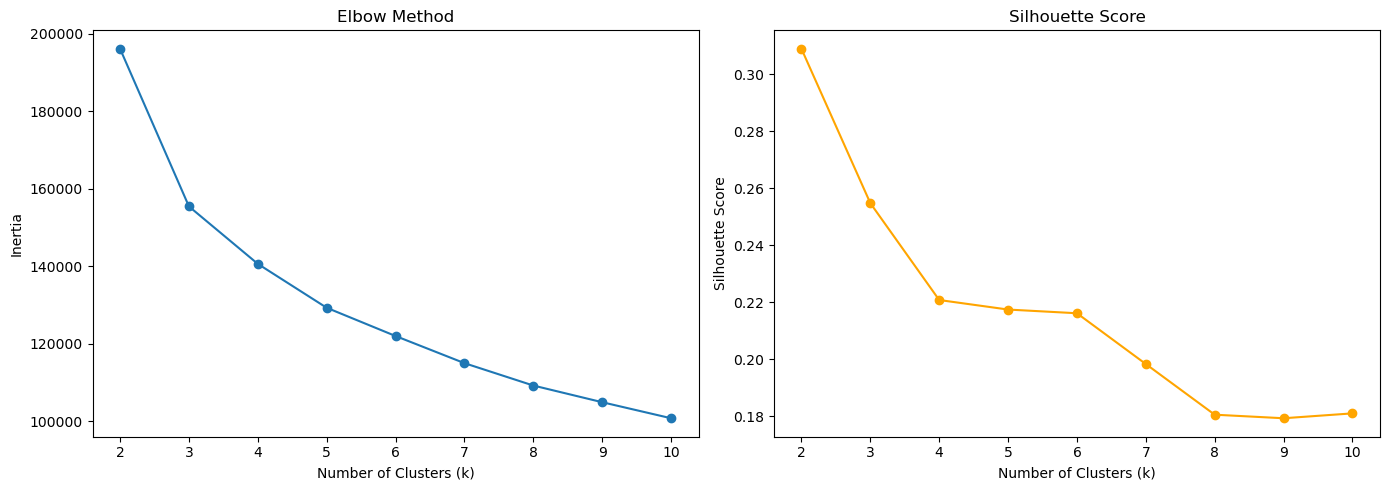

In [ ]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_saude_st)

In [ ]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_st = fit_kmeans(df_saude_st, 4)
print(kmeans_profile_st)

Silhouette Score: 0.2207
Cluster sizes:
0     5992
1    11420
2     6995
3     8631
Name: count, dtype: int64
                                  cluster_0  cluster_1  cluster_2  cluster_3
lifetime_spend_vegetables         -0.715995  -0.405109   1.592082  -0.257216
lifetime_spend_meat                0.374127   0.281170  -1.619319   0.680617
lifetime_spend_fish                0.445693   0.040044  -1.369430   0.747454
lifetime_spend_alcohol_drinks      0.645541  -0.555976  -0.567181   0.747144
lifetime_spend_nonalcohol_drinks   0.264336  -0.922315   0.333032   0.766930
lifetime_spend_videogames          0.940650  -0.580305  -0.387417   0.428768
typical_hour                       1.398001  -0.353378  -0.029902  -0.478749
age                               -0.076597  -0.222438   0.139986   0.234041


In [ ]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_st = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_st = kmeans_opt_st.fit_predict(df_saude_st)

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


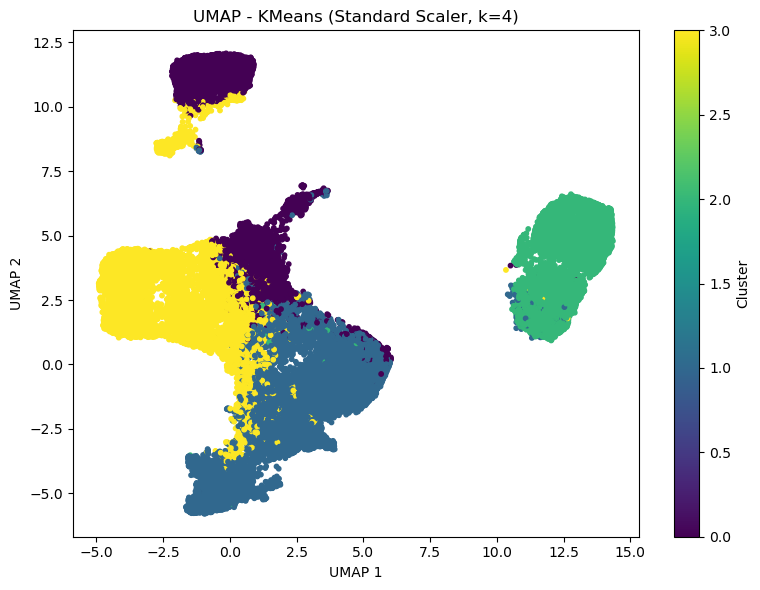

array([[12.219071  ,  3.4300091 ],
       [12.1149    ,  3.5292835 ],
       [ 4.127259  , -0.6509028 ],
       ...,
       [12.438246  ,  1.9728467 ],
       [ 0.67334634,  1.1506593 ],
       [ 2.112141  , -3.1642618 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_st, labels_kmeans_st, title="UMAP - KMeans (Standard Scaler, k=4)")

## 2.2 Mean Shift

In [ ]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_st = MeanShift(bin_seeding=True)
labels_ms_st = mean_shift_st.fit_predict(df_saude_st)
print("Standard Scaler MeanShift cluster count:", len(np.unique(labels_ms_st)))
if len(np.unique(labels_ms_st)) > 1:
    print(f"Standard Scaler MeanShift silhouette: {silhouette_score(df_saude_st, labels_ms_st):.4f}")
else:
    print("Standard Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_st).value_counts().sort_index())

Standard Scaler MeanShift cluster count: 1
Standard Scaler MeanShift silhouette: not defined (single cluster)
0    33038
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


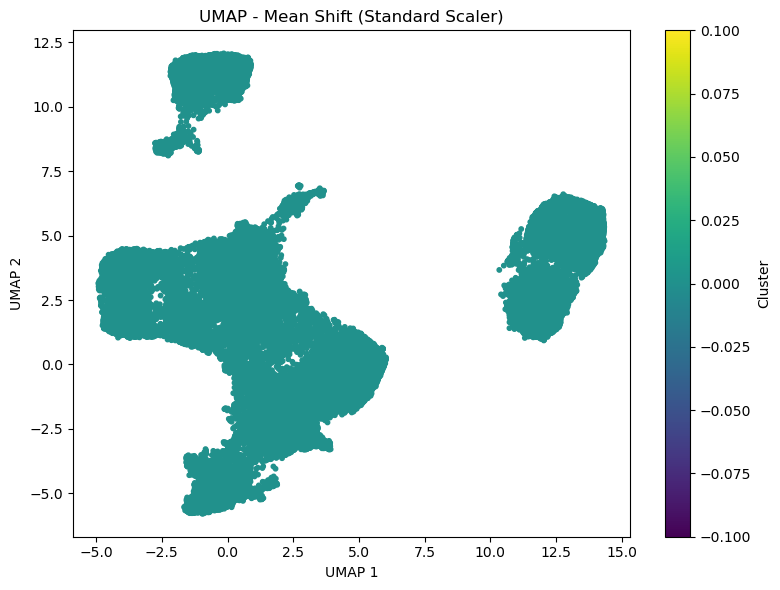

array([[12.219071  ,  3.4300091 ],
       [12.1149    ,  3.5292835 ],
       [ 4.127259  , -0.6509028 ],
       ...,
       [12.438246  ,  1.9728467 ],
       [ 0.67334634,  1.1506593 ],
       [ 2.112141  , -3.1642618 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_st, labels_ms_st, title="UMAP - Mean Shift (Standard Scaler)")

## 2.3 Hierarchical Clustering

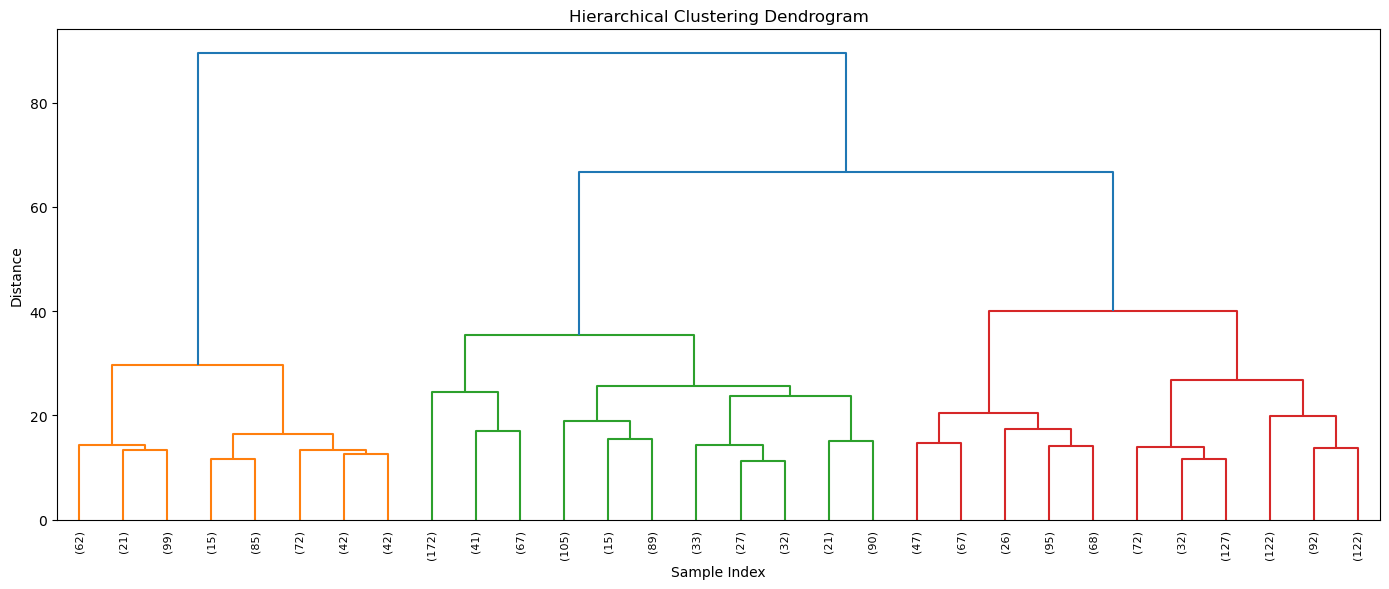

Silhouette Score: 0.1637
Cluster sizes:
0    8726
1    6961
2    7585
3    6978
4    2788
Name: count, dtype: int64


In [ ]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_st, labels_hierarchical_st = fit_hierarchical(df_saude_st, 5, method='ward')

c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


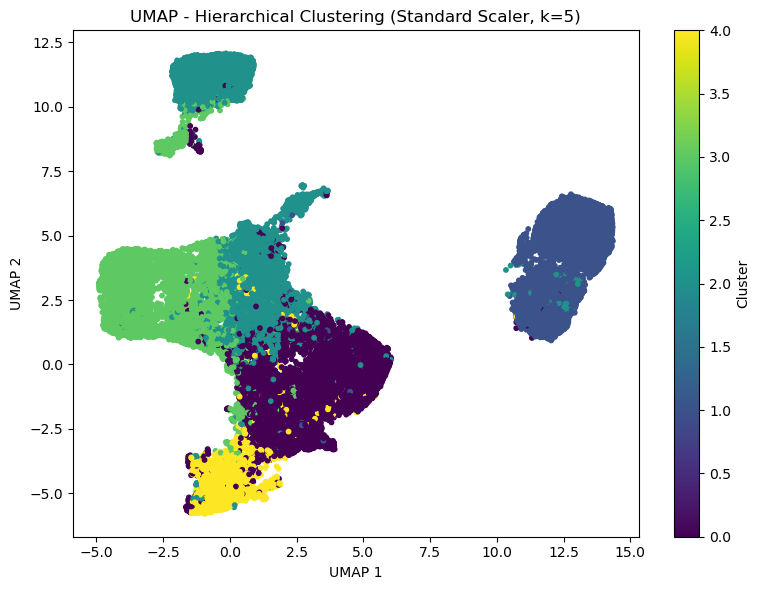

array([[12.219071  ,  3.4300091 ],
       [12.1149    ,  3.5292835 ],
       [ 4.127259  , -0.6509028 ],
       ...,
       [12.438246  ,  1.9728467 ],
       [ 0.67334634,  1.1506593 ],
       [ 2.112141  , -3.1642618 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_st, labels_hierarchical_st, title="UMAP - Hierarchical Clustering (Standard Scaler, k=5)")

## 2.4 DBSCAN

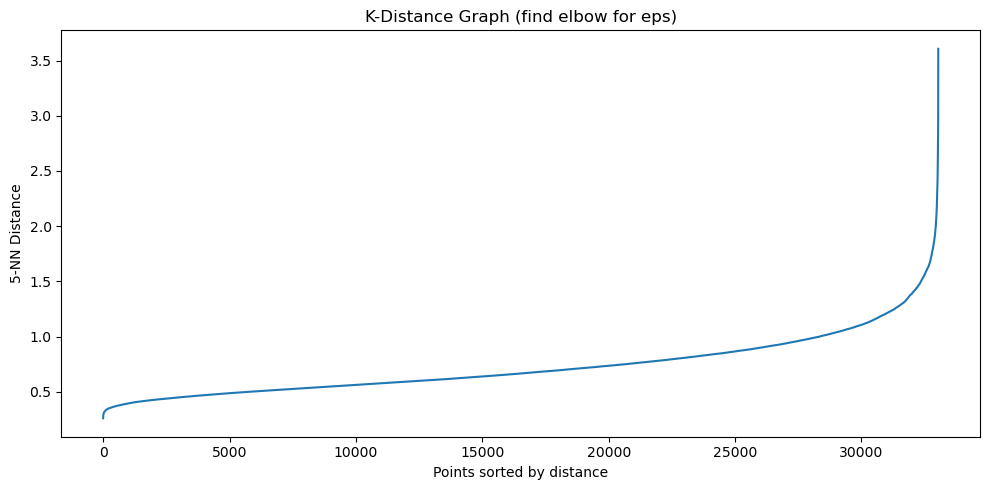

In [ ]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_saude_st, n_neighbors=5)

In [ ]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_saude_st, 2.5, min_samples=5))

Number of clusters: 1
Noise points: 7 (0.02%)
Cluster sizes:
-1        7
 0    33031
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


Number of clusters: 1
Noise points: 1 (0.00%)
Cluster sizes:
-1        1
 0    33037
Name: count, dtype: int64


c:\Users\maria\anaconda3\envs\MachineLearningI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


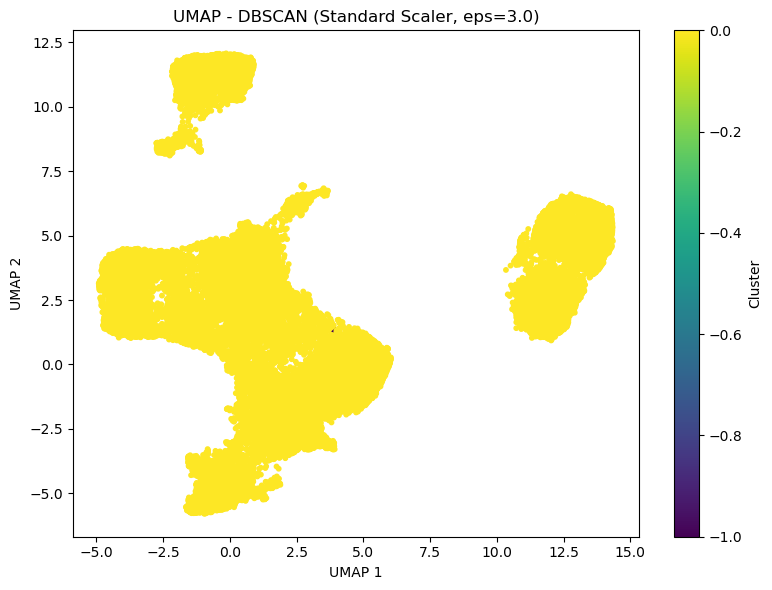

array([[12.219071  ,  3.4300091 ],
       [12.1149    ,  3.5292835 ],
       [ 4.127259  , -0.6509028 ],
       ...,
       [12.438246  ,  1.9728467 ],
       [ 0.67334634,  1.1506593 ],
       [ 2.112141  , -3.1642618 ]], shape=(33038, 2), dtype=float32)

In [ ]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_st, labels_dbscan_st = fit_dbscan(df_saude_st, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_st, labels_dbscan_st, title="UMAP - DBSCAN (Standard Scaler, eps=3.0)")

In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_saude_st, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## 2.5 Self-Organizing Map (SOM)

In [ ]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_st = fit_som(df_saude_st, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

KeyboardInterrupt: 

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_st = get_som_cluster_labels(som_result_st['weights'], n_clusters=5, random_state=42)
print(neuron_labels_st)

In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_st, neuron_labels_st = assign_som_clusters(som_result_st['weights'], df_saude_st, n_clusters=5, random_state=42)
print((labels_som_st, neuron_labels_st))

# 3. Clustering with Robust Scaler

## 3.1 K-Means

In [ ]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_saude_rb)

In [ ]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_rb = fit_kmeans(df_saude_rb, 4)
print(kmeans_profile_rb)

In [ ]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_rb = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_rb = kmeans_opt_rb.fit_predict(df_saude_rb)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_rb, labels_kmeans_rb, title="UMAP - KMeans (Robust Scaler, k=4)")

## 3.2 Mean Shift

In [ ]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_rb = MeanShift(bin_seeding=True)
labels_ms_rb = mean_shift_rb.fit_predict(df_saude_rb)
print("Robust Scaler MeanShift cluster count:", len(np.unique(labels_ms_rb)))
if len(np.unique(labels_ms_rb)) > 1:
    print(f"Robust Scaler MeanShift silhouette: {silhouette_score(df_saude_rb, labels_ms_rb):.4f}")
else:
    print("Robust Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_rb).value_counts().sort_index())

In [ ]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_rb, labels_ms_rb, title="UMAP - Mean Shift (Robust Scaler)")

## 3.3 Hierarchical Clustering

In [ ]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_rb, labels_hierarchical_rb = fit_hierarchical(df_saude_rb, 5, method='ward')

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_rb, labels_hierarchical_rb, title="UMAP - Hierarchical Clustering (Robust Scaler, k=5)")

## 3.4 DBSCAN

In [ ]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_saude_rb, n_neighbors=5)

In [ ]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_saude_rb, 2.5, min_samples=5))

In [ ]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_rb, labels_dbscan_rb = fit_dbscan(df_saude_rb, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_rb, labels_dbscan_rb, title="UMAP - DBSCAN (Robust Scaler, eps=3.0)")

In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_saude_rb, 3.5, min_samples=5))

## 3.5 Self-Organizing Map (SOM)

In [ ]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_rb = fit_som(df_saude_rb, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_rb = get_som_cluster_labels(som_result_rb['weights'], n_clusters=5, random_state=42)
print(neuron_labels_rb)

In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_rb, neuron_labels_rb = assign_som_clusters(som_result_rb['weights'], df_saude_rb, n_clusters=5, random_state=42)
print((labels_som_rb, neuron_labels_rb))

# 4. Clustering with MinMax Scaler

## 4.1 K-Means

In [ ]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_saude_mm)

In [ ]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_mm = fit_kmeans(df_saude_mm, 4)
print(kmeans_profile_mm)

In [ ]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_mm = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_mm = kmeans_opt_mm.fit_predict(df_saude_mm)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_mm, labels_kmeans_mm, title="UMAP - KMeans (MinMax Scaler, k=4)")

## 4.2 Mean Shift

In [ ]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_mm = MeanShift(bin_seeding=True)
labels_ms_mm = mean_shift_mm.fit_predict(df_saude_mm)
print("MinMax Scaler MeanShift cluster count:", len(np.unique(labels_ms_mm)))
if len(np.unique(labels_ms_mm)) > 1:
    print(f"MinMax Scaler MeanShift silhouette: {silhouette_score(df_saude_mm, labels_ms_mm):.4f}")
else:
    print("MinMax Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_mm).value_counts().sort_index())

In [ ]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_mm, labels_ms_mm, title="UMAP - Mean Shift (MinMax Scaler)")

## 4.3 Hierarchical Clustering

In [ ]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_mm, labels_hierarchical_mm = fit_hierarchical(df_saude_mm, 5, method='ward')

In [ ]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_mm, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=5)")

## 4.4 DBSCAN

In [ ]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_saude_mm, n_neighbors=5)

In [ ]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_saude_mm, 2.5, min_samples=5))

In [ ]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_mm, labels_dbscan_mm = fit_dbscan(df_saude_mm, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_saude_mm, labels_dbscan_mm, title="UMAP - DBSCAN (MinMax Scaler, eps=3.0)")

In [ ]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_saude_mm, 3.5, min_samples=5))

## 4.5 Self-Organizing Map (SOM)

In [ ]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_mm = fit_som(df_saude_mm, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

In [ ]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_mm = get_som_cluster_labels(som_result_mm['weights'], n_clusters=5, random_state=42)
print(neuron_labels_mm)

In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_mm, neuron_labels_mm = assign_som_clusters(som_result_mm['weights'], df_saude_mm, n_clusters=5, random_state=42)
print((labels_som_mm, neuron_labels_mm))

# 5. Model Comparison

In [ ]:
# Compare all fitted models using their Silhouette Scores to find the best configuration
labels_dict_st = {
    'KMeans (k=4)': labels_kmeans_st,
    'Hierarchical (k=5)': labels_hierarchical_st,
    'DBSCAN (eps=3.0)': labels_dbscan_st,
    'MeanShift': labels_ms_st,
    'SOM (k=5)': labels_som_st
}
print("--- Standard Scaler Comparison ---")
compare_models(df_saude_st, labels_dict_st)

# Compare all fitted models for Robust Scaler
labels_dict_rb = {
    'KMeans (k=4)': labels_kmeans_rb,
    'Hierarchical (k=5)': labels_hierarchical_rb,
    'DBSCAN (eps=3.0)': labels_dbscan_rb,
    'MeanShift': labels_ms_rb,
    'SOM (k=5)': labels_som_rb
}
print("\n--- Robust Scaler Comparison ---")
compare_models(df_saude_rb, labels_dict_rb)

# Compare all fitted models for MinMax Scaler
labels_dict_mm = {
    'KMeans (k=4)': labels_kmeans_mm,
    'Hierarchical (k=5)': labels_hierarchical_mm,
    'DBSCAN (eps=3.0)': labels_dbscan_mm,
    'MeanShift': labels_ms_mm,
    'SOM (k=5)': labels_som_mm
}
print("\n--- MinMax Scaler Comparison ---")
compare_models(df_saude_mm, labels_dict_mm)